In [25]:
from datasets import load_dataset
import torch
import numpy as np
import pandas as pd
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
import tqdm
import math

import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [26]:
ds = load_dataset("Godseye1311/gravitational-waves-strain")

Resolving data files:   0%|          | 0/128 [00:00<?, ?it/s]

In [27]:
def prepare_data(example):
    h_noisy = np.array(np.log(example['hNoisy']))  # Input: (length,)
    params = np.array([np.log(example['M1']), np.log(example['M2']), np.log(example['R'])])

    # Normalize strain to [-1,1] per sequence (important for CNNs)

    return {
        'input': torch.tensor(h_noisy).unsqueeze(0),  # Shape: (1, length)
        'target': torch.tensor(np.log(params))               # Shape: (3,)
    }

train_ds = ds['train'].map(prepare_data).with_format("torch")


In [28]:
train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)

In [29]:
class GWCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=8, stride=2, padding=3), nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=6, stride=2, padding=2), nn.ReLU(),
            nn.Conv1d(64, 128, kernel_size=4, stride=2, padding=1), nn.ReLU(),
            nn.Conv1d(128, 256, kernel_size=3, stride=2, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool1d(8)  # Fixed output size
        )
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256*8, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(128, 3)  # M1, M2, R outputs
        )

    def forward(self, x):
        x = self.conv_layers(x)
        return self.fc_layers(x)

In [30]:
device = torch.device('cuda')
print(device)

model = GWCNN().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
criterion = nn.MSELoss()
scheduler = ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

for epoch in range(20):
    model.train()
    total_loss = 0
    progress_bar = tqdm.tqdm(train_loader, desc=f"Epoch {epoch+1}")
    for batch in progress_bar:
        inputs = batch['input'].to(device)
        targets = batch['target'].to(device)

        optimizer.zero_grad()
        preds = model(inputs)
        loss = criterion(preds, targets)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    scheduler.step(avg_loss)
    print(f"Epoch {epoch+1}: Loss = {avg_loss:.6f}, LR = {optimizer.param_groups[0]['lr']:.2e}")

cuda


Epoch 1: 100%|██████████| 1024/1024 [02:53<00:00,  5.89it/s]


Epoch 1: Loss = 0.422923, LR = 1.00e-03


Epoch 2: 100%|██████████| 1024/1024 [02:49<00:00,  6.05it/s]


Epoch 2: Loss = 0.045732, LR = 1.00e-03


...

Epoch 18: Loss = 0.000063, LR = 1.00e-03


Epoch 19: 100%|██████████| 1024/1024 [02:52<00:00,  5.94it/s]


Epoch 19: Loss = 0.000061, LR = 1.00e-03


Epoch 20: 100%|██████████| 1024/1024 [02:54<00:00,  5.85it/s]

Epoch 20: Loss = 0.000060, LR = 1.00e-03


In [31]:
def simulate_waveforms(m1, m2, r, tmax, n_samples=4096, noise_std=0.01):
    G = 6.6743e-11
    c = 299792458

    chirp_mass = (m1*m2)**(3/5) / (m1 + m2)**(1/5)
    K = (96/5) * (math.pow(G, 5/3)) * math.pow(chirp_mass, 5/3)

    omega0 = math.sqrt(G * chirp_mass / math.pow(r, 3))
    tc = (3/(8*K)) * math.pow(omega0, -8/3)
    t = np.linspace(0, min(tc, tmax), n_samples)

    omega = math.pow(8*K/3, -3/8) * (tc - t)
    phi = np.cumsum(omega * (t[1]-t[0]))
    h = (4*G*chirp_mass/(math.pow(c, 2)*r)) * np.power(omega * chirp_mass/2, 2/3) * np.cos(2 * phi)

    noise = np.random.normal(0, noise_std, size=h.shape)
    return t, h, h + noise

In [32]:
def sample_parameters():
    m1 = np.random.uniform(1, 100) * 1.98847e30
    m2 = np.random.uniform(1, 100) * 1.98847e30
    r  = np.random.uniform(3e17, 5e17)  # 1e8–1e11 m
    return m1, m2, r

In [33]:
M1, M2, R = sample_parameters()
t, h, h_noisy = simulate_waveforms(M1, M2, R, tmax=1, noise_std=1e-12, n_samples=128)

In [34]:
model.eval()
h_noisy = np.array(np.log(h_noisy), dtype=np.float32)
inputs = torch.tensor(h_noisy).unsqueeze(0).unsqueeze(0).to(device)
output = model(inputs)

In [35]:
pred_M1 = np.exp(np.exp(output.flatten()[0].cpu().detach().numpy()))
pred_M2 = np.exp(np.exp(output.flatten()[1].cpu().detach().numpy()))
pred_R = np.exp(np.exp(output.flatten()[2].cpu().detach().numpy()))

In [36]:
M1, M2, R

(1.915256092022903e+32, 8.181212640670667e+31, 3.88189882921626e+17)

In [37]:
pred_M1, pred_M2, pred_R

(np.float32(1.1854847e+32),
 np.float32(1.2545406e+32),
 np.float32(3.4998393e+17))

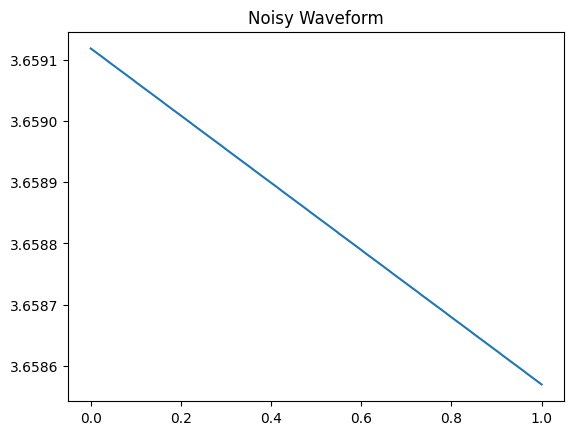

In [38]:
plt.plot(t, h_noisy)
plt.title("Noisy Waveform")
plt.show()